## Setup: imports and database connection

In [1]:
import sys
sys.path.append("/Users/azadeh_sereshki/Documents/Projects/eicu-mortality-prediction/src")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from db import get_engine

## Configure plots to look clean

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

engine = get_engine()
print("Ready to query.")

Ready to query.


## Load the cohort into pandas

In [4]:
# Pull the cohort view into a pandas DataFrame
cohort = pd.read_sql("SELECT * FROM cohort;", engine)
print(f"Cohort shape: {cohort.shape}")
print(f"Columns: {list(cohort.columns)[:8]}... (showing first 8 of {len(cohort.columns)})")
cohort.head()

Cohort shape: (1424, 30)
Columns: ['patientunitstayid', 'patienthealthsystemstayid', 'gender', 'age', 'ethnicity', 'hospitalid', 'wardid', 'apacheadmissiondx']... (showing first 8 of 30)


,patientunitstayid,patienthealthsystemstayid,gender,age,ethnicity,hospitalid,wardid,apacheadmissiondx,admissionheight,hospitaladmittime24,...,unitvisitnumber,unitstaytype,admissionweight,dischargeweight,unitdischargetime24,unitdischargeoffset,unitdischargelocation,unitdischargestatus,uniquepid,age_numeric
0,147784,134042,Female,60,Hispanic,67,109,Coma/change in level of consciousness (for hep...,154.9,05:06:00,...,1,admit,95.6,97.6,20:47:00,2381,Floor,Alive,002-10424,60
1,151179,136669,Female,59,Caucasian,66,90,"Sepsis, cutaneous/soft tissue",149.9,17:05:00,...,1,admit,NaN,73.0,02:50:00,4904,Floor,Alive,002-10079,59
2,151867,137216,Male,44,Caucasian,68,103,"GI perforation/rupture, surgery for",172.7,18:43:00,...,1,admit,NaN,84.1,06:18:00,1883,Floor,Alive,002-10323,44
3,151900,137239,Female,66,Caucasian,73,97,"Sepsis, pulmonary",165.1,10:02:00,...,1,admit,86.8,79.0,20:05:00,3460,Floor,Alive,002-10052,66
4,152954,138053,Female,41,Caucasian,71,87,"Respiratory - medical, other",170.2,01:56:00,...,1,admit,81.0,80.6,00:20:00,4224,Floor,Alive,002-10393,41


## Mortality by age group

  age_group  n_patients  deaths  mortality_pct
0       <40       165.0     3.0       1.818182
1     40-54       214.0    10.0       4.672897
2     55-69       429.0    26.0       6.060606
3     70-84       472.0    55.0      11.652542
4       85+       144.0    24.0      16.666667


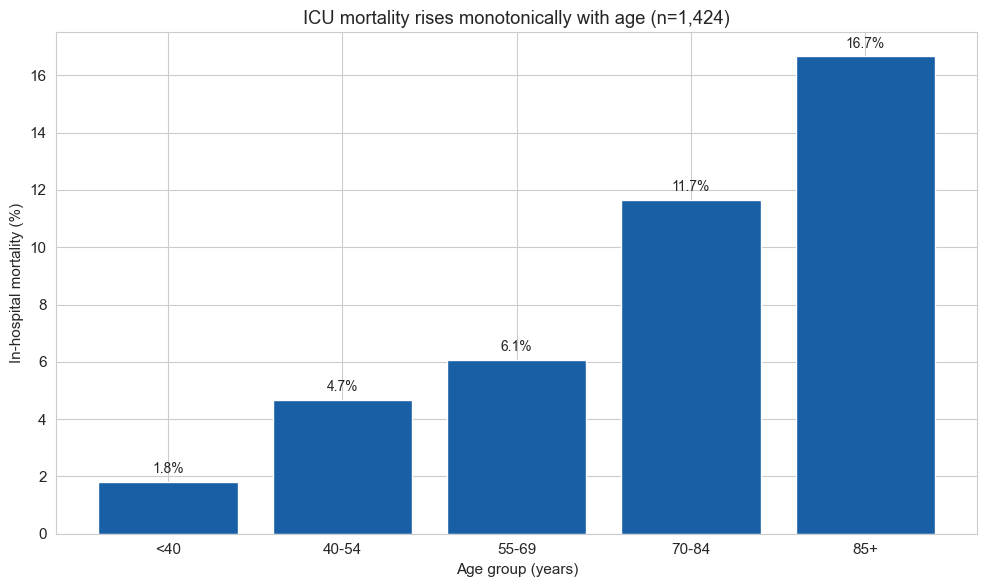

In [5]:
# Compute mortality rate by age group
age_bins = [0, 40, 55, 70, 85, 100]
age_labels = ["<40", "40-54", "55-69", "70-84", "85+"]
cohort["age_group"] = pd.cut(cohort["age_numeric"], bins=age_bins, labels=age_labels, right=False)

mortality_by_age = (
    cohort.groupby("age_group", observed=True)
    .apply(lambda g: pd.Series({
        "n_patients": len(g),
        "deaths": (g["hospitaldischargestatus"] == "Expired").sum(),
        "mortality_pct": 100.0 * (g["hospitaldischargestatus"] == "Expired").sum() / len(g),
    }))
    .reset_index()
)
print(mortality_by_age)

# Plot it
fig, ax = plt.subplots()
bars = ax.bar(mortality_by_age["age_group"].astype(str), mortality_by_age["mortality_pct"], color="#185FA5")
ax.set_ylabel("In-hospital mortality (%)")
ax.set_xlabel("Age group (years)")
ax.set_title("ICU mortality rises monotonically with age (n=1,424)")

# Annotate each bar with the mortality percentage
for bar, pct in zip(bars, mortality_by_age["mortality_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{pct:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()